In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset=pd.read_csv("quality.csv")

In [3]:
dataset

,MemberID,InpatientDays,ERVisits,OfficeVisits,Narcotics,DaysSinceLastERVisit,Pain,TotalVisits,ProviderCount,MedicalClaims,ClaimLines,StartedOnCombination,AcuteDrugGapSmall,PoorCare
0,1,0,0,18,1,731.000000,10,18,21,93,222,False,0,0
1,2,1,1,6,1,411.000000,0,8,27,19,115,False,1,0
2,3,0,0,5,3,731.000000,10,5,16,27,148,False,5,0
3,4,0,1,19,0,158.000000,34,20,14,59,242,False,0,0
4,5,8,2,19,3,449.000000,10,29,24,51,204,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,127,1,1,5,3,444.000000,0,7,11,11,36,False,0,0
127,128,1,0,3,2,731.000000,0,4,35,18,106,False,2,0
128,129,15,11,5,9,180.958333,95,31,56,43,265,False,3,0
129,130,0,2,14,1,216.958333,5,16,26,41,138,False,1,1


In [4]:
dataset.isnull().sum()

MemberID                0
InpatientDays           0
ERVisits                0
OfficeVisits            0
Narcotics               0
DaysSinceLastERVisit    0
Pain                    0
TotalVisits             0
ProviderCount           0
MedicalClaims           0
ClaimLines              0
StartedOnCombination    0
AcuteDrugGapSmall       0
PoorCare                0
dtype: int64

In [6]:
import seaborn as sns

C:\Users\s0741\AppData\Local\Temp\ipykernel_1768\3896851862.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset["OfficeVisits"])


<Axes: xlabel='OfficeVisits', ylabel='Density'>

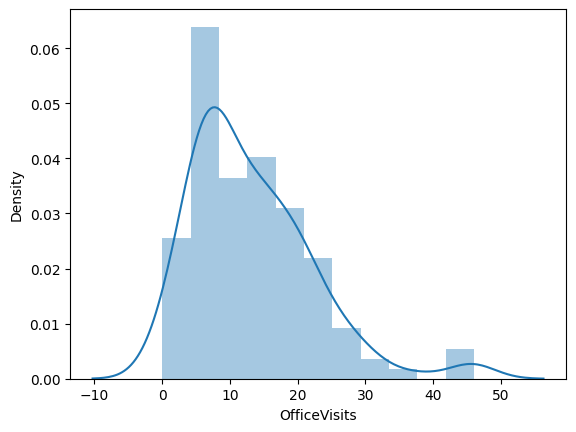

In [22]:
sns.distplot(dataset["OfficeVisits"])

In [47]:
def get_pdf_probability(dataset, startrange, endrange):
    import matplotlib.pyplot as plt
    from scipy.stats import norm
    import seaborn as sns
    import numpy as np

    # Plot
    sns.distplot(dataset, kde=True, color='blue')
    plt.axvline(startrange, color="red")
    plt.axvline(endrange, color="red")

    # Convert to array (safe)
    sample = np.array(dataset)

    # Mean & Std
    sample_mean = sample.mean()
    sample_std = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))

    # Normal distribution
    dist = norm(sample_mean, sample_std)

    # BEST WAY: use CDF (accurate probability)
    prob = dist.cdf(endrange) - dist.cdf(startrange)

    print("The area between range({}, {}) is: {}".format(startrange, endrange, prob))

    plt.show()
    return prob

Mean=13.229, Standard Deviation=9.042
The area between range(10, 20) is: 0.41250413137146874


C:\Users\s0741\AppData\Local\Temp\ipykernel_1768\330709157.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset, kde=True, color='blue')


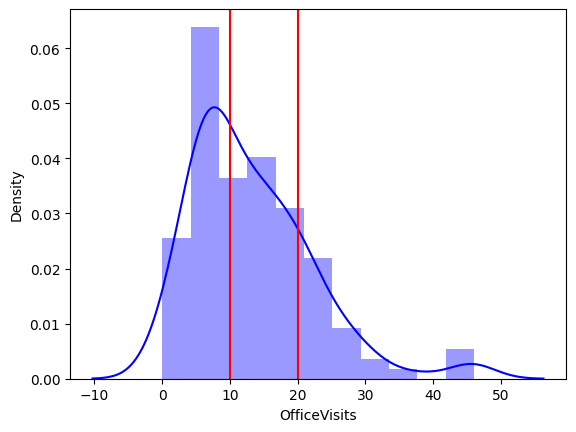

np.float64(0.41250413137146874)

In [48]:
get_pdf_probability(dataset["OfficeVisits"], 10, 20)